In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 66.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7d0726bd3f118d9cdc46bc4217b57198809914b4f28d97b57535f98d6bb52f31
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


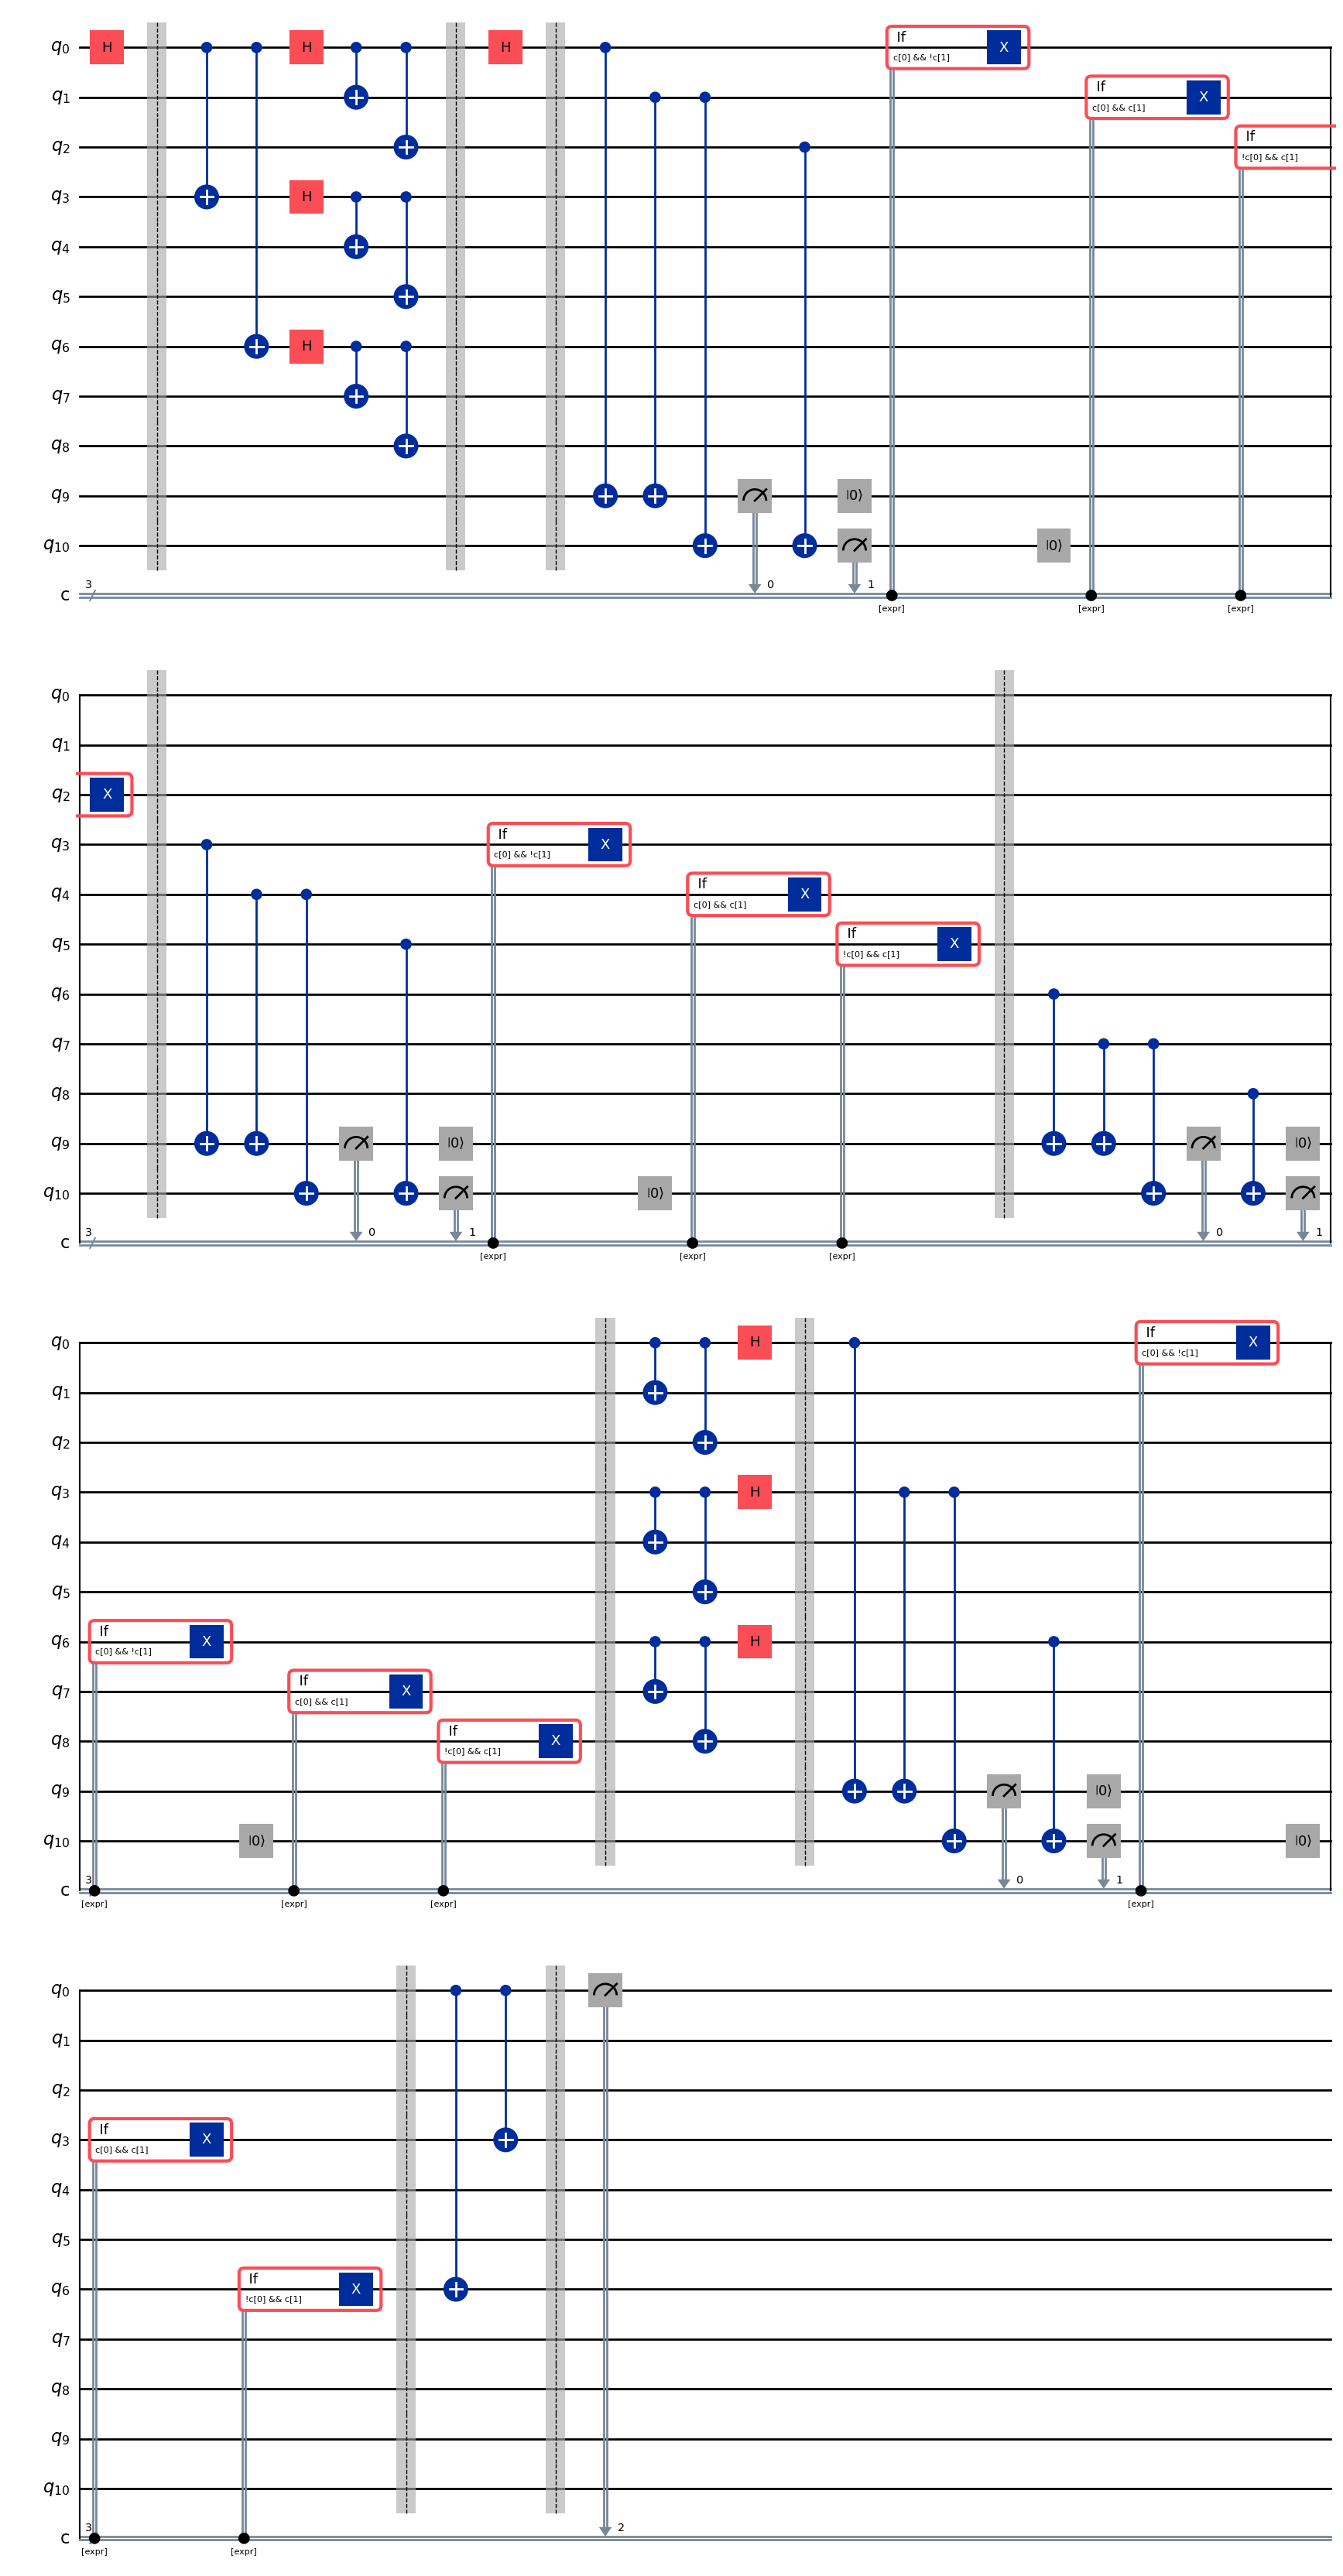

In [7]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.
shor = QuantumCircuit(11, 3)

shor.h(0)
shor.barrier()

shor.cx(0, 3)
shor.cx(0, 6)
shor.h(0)
shor.h(3)
shor.h(6)


shor.cx(0, 1)
shor.cx(0, 2)
shor.cx(3, 4)
shor.cx(3, 5)
shor.cx(6, 7)
shor.cx(6, 8)
shor.barrier()


shor.h(0)
shor.barrier()



def correct_block(qc, qA, qB, qC):
    qc.cx(qA, 9)
    qc.cx(qB, 9)

    qc.cx(qB, 10)
    qc.cx(qC, 10)

    qc.measure([9, 10], [0, 1])


    with qc.if_test(expr.logic_and(qc.clbits[0], expr.logic_not(qc.clbits[1]))):
        qc.x(qA)
    with qc.if_test(expr.logic_and(qc.clbits[0], qc.clbits[1])):
        qc.x(qB)
    with qc.if_test(expr.logic_and(expr.logic_not(qc.clbits[0]), qc.clbits[1])):
        qc.x(qC)

    qc.reset(9)
    qc.reset(10)
    qc.barrier()



correct_block(shor, 0, 1, 2)
correct_block(shor, 3, 4, 5)
correct_block(shor, 6, 7, 8)


shor.cx(0, 1)
shor.cx(0, 2)
shor.cx(3, 4)
shor.cx(3, 5)
shor.cx(6, 7)
shor.cx(6, 8)

shor.h(0)
shor.h(3)
shor.h(6)
shor.barrier()

correct_block(shor, 0, 3, 6)


shor.cx(0, 6)
shor.cx(0, 3)
shor.barrier()

shor.measure(0, 2)

shor.draw("mpl")


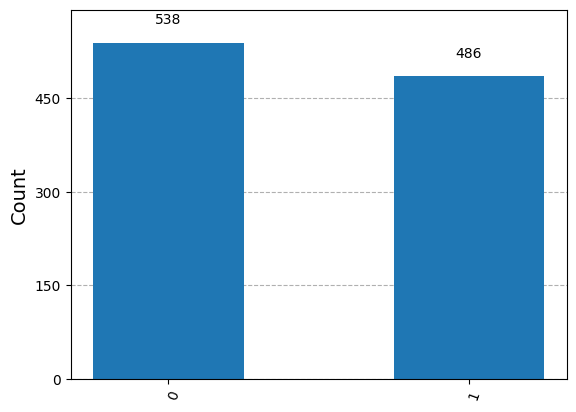

In [8]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=11, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts, indices=[2])
plot_histogram(mcounts)